# 11 — Cross-Market Transferability: Portugal → Philippines

**The question this notebook answers:** if we take the exact same pipeline that was built for the Portuguese hotel dataset and point it at a booking export from a Philippine resort, what carries over?

We separate two very different claims:

1. **Method transferability** — does the *pipeline* (cleaning → features → models → calibration → thresholds) run end-to-end on a new market's data without code changes? This is an engineering claim, and it is testable with any amount of data.
2. **Finding transferability** — do the *conclusions* (which algorithms rank best, which features matter) hold in the new market? This is a statistical claim, and it is limited by the size of the new dataset.

**Honest scale warning, up front:** the Philippine dataset is a real PMS export from Punta Villa Resort with **193 bookings** (29 cancellations, 15.0% rate) — roughly 600× smaller than the Portugal dataset. Every Philippine number in this notebook is **directional evidence from a pilot study**, not a benchmark. The cross-validation design below (stratified 10-fold) is chosen specifically to use all 193 rows as efficiently as possible.

All tables load pre-computed results from `reports/cv/` and `reports/ph/` (producers documented in `docs/provenance.md`); nothing is retrained here.

In [1]:
# --- Setup ---
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.eval.notebook_utils import setup_plotting, save_thesis_figure

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

style = setup_plotting()
FIG_DIR = Path("../reports/figures/thesis")
FIG_DIR.mkdir(parents=True, exist_ok=True)
CV_DIR = Path("../reports/cv")
PH_DIR = Path("../reports/ph")


def load_json(path):
    """Load a results JSON, or explain why it is unavailable (private-data producer)."""
    p = Path(path)
    if not p.exists():
        print(f"[unavailable] {p} — produced from the private PH dataset; see docs/provenance.md")
        return None
    return json.loads(p.read_text(encoding="utf-8"))


ph_cv = load_json(CV_DIR / "philippine_stratified_10fold_summary.json")
pt_cv = load_json(CV_DIR / "portugal_stratified_10fold_summary.json")
transfer = load_json(PH_DIR / "ph_transferability.json")
ph_shap = load_json(PH_DIR / "shap_analysis.json")
print("Loaded:", sum(x is not None for x in (ph_cv, pt_cv, transfer, ph_shap)), "of 4 result files")

Loaded: 4 of 4 result files


## 11.1 The two datasets, side by side

**How to read the table:** the point is not that the datasets are similar — it is to make their *differences* explicit before any comparison, so nobody mistakes the pilot for a replication.

In [2]:
if ph_cv and pt_cv:
    pt_meta, ph_meta = pt_cv["dataset_meta"], ph_cv["dataset_meta"]
    diag = (transfer or {}).get("dataset_diagnostics", {})
    rows = [
        ("Setting", "City + resort hotels, Portugal", "Single resort (Punta Villa), Philippines"),
        ("Source", "Public research dataset (Antonio et al.)", "Private PMS export"),
        ("Rows used", f"{pt_meta['n_rows_used']:,}", f"{ph_meta['n_rows_used']:,}"),
        ("Cancellations", f"{pt_meta['n_positive']:,}", f"{ph_meta['n_positive']:,}"),
        ("Cancellation rate", f"{pt_meta['positive_rate']:.1%}", f"{ph_meta['positive_rate']:.1%}"),
        ("Model features available", len(pt_meta["feature_cols"]), len(ph_meta["feature_cols"])),
        ("Duplicate feature vectors", "~27% of rows (group bookings)", f"{diag.get('duplicate_rate', 0.0):.0%} (all rows unique)"),
        ("CV design", f"stratified {pt_meta['n_splits']}-fold", f"stratified {ph_meta['n_splits']}-fold"),
    ]
    tbl = pd.DataFrame(rows, columns=["", "Portugal", "Philippines"])
    display(
        tbl.style.hide(axis="index").set_caption(
            "Table 11.1 — Dataset characteristics: benchmark market vs pilot market"
        )
    )

,Portugal,Philippines
Setting,"City + resort hotels, Portugal","Single resort (Punta Villa), Philippines"
Source,Public research dataset (Antonio et al.),Private PMS export
Rows used,"119,209",193
Cancellations,"44,199",29
Cancellation rate,37.1%,15.0%
Model features available,34,18
Duplicate feature vectors,~27% of rows (group bookings),0% (all rows unique)
CV design,stratified 10-fold,stratified 10-fold


**Key takeaway:** the Philippine pilot is ~600× smaller, has roughly half the cancellation rate (15% vs 37%), and — unlike Portugal — contains no duplicated group-booking rows. Because the positive-rate baselines differ, PR-AUC values are **not comparable in magnitude across markets**; we compare *algorithm rankings*, not raw scores.

## 11.2 The comparison table: 7 algorithms × 2 markets

Both markets were evaluated with the **same protocol**: stratified 10-fold cross-validation, identical algorithm list, same random seed. **How to read it:** within each market, higher is better; across markets, compare the *rank order*, not the values (different class balance → different PR-AUC baselines: 0.37 vs 0.15).

In [3]:
if ph_cv and pt_cv:
    def table_for(summary):
        out = {}
        for entry in summary["per_algorithm"]:
            out[entry["algorithm"]] = {
                "roc": entry["roc_auc"]["mean"], "roc_sd": entry["roc_auc"]["std"],
                "pr": entry["pr_auc"]["mean"], "pr_sd": entry["pr_auc"]["std"],
            }
        return out

    pt_t, ph_t = table_for(pt_cv), table_for(ph_cv)
    algos = [a for a in pt_t if a in ph_t]
    pt_rank = {e["algorithm"]: e["rank"] for e in pt_cv["ranking"]}
    ph_rank = {e["algorithm"]: e["rank"] for e in ph_cv["ranking"]}
    rows = []
    for a in algos:
        rows.append({
            "Algorithm": a,
            "PT ROC-AUC": f"{pt_t[a]['roc']:.3f} ± {pt_t[a]['roc_sd']:.3f}",
            "PT PR-AUC": f"{pt_t[a]['pr']:.3f} ± {pt_t[a]['pr_sd']:.3f}",
            "PT rank": pt_rank.get(a),
            "PH ROC-AUC": f"{ph_t[a]['roc']:.3f} ± {ph_t[a]['roc_sd']:.3f}",
            "PH PR-AUC": f"{ph_t[a]['pr']:.3f} ± {ph_t[a]['pr_sd']:.3f}",
            "PH rank": ph_rank.get(a),
        })
    comp = pd.DataFrame(rows).sort_values("PT rank").reset_index(drop=True)
    display(
        comp.style.hide(axis="index").set_caption(
            "Table 11.2 — Stratified 10-fold CV, mean ± std across folds (ranks by PR-AUC within market)"
        )
    )

    from scipy.stats import spearmanr
    shared = [a for a in algos if pt_rank.get(a) and ph_rank.get(a)]
    rho, pval = spearmanr([pt_rank[a] for a in shared], [ph_rank[a] for a in shared])
    print(f"Rank agreement across markets (Spearman rho over {len(shared)} algorithms): "
          f"{rho:.2f} (p={pval:.3f})")
    print(f"#1 by PR-AUC — Portugal: {pt_cv['ranking'][0]['algorithm']} | "
          f"Philippines: {ph_cv['ranking'][0]['algorithm']}")

Algorithm,PT ROC-AUC,PT PR-AUC,PT rank,PH ROC-AUC,PH PR-AUC,PH rank
LightGBM,0.947 ± 0.002,0.922 ± 0.002,1,0.872 ± 0.129,0.731 ± 0.197,4
GradientBoosting,0.940 ± 0.002,0.912 ± 0.002,2,0.884 ± 0.151,0.748 ± 0.204,2
XGBoost,0.937 ± 0.002,0.908 ± 0.003,3,0.870 ± 0.155,0.749 ± 0.160,1
LogisticRegression,0.901 ± 0.002,0.860 ± 0.003,4,0.886 ± 0.120,0.739 ± 0.227,3
DecisionTree,0.876 ± 0.003,0.798 ± 0.004,5,0.821 ± 0.082,0.380 ± 0.164,6
GaussianNB,0.814 ± 0.004,0.749 ± 0.005,6,0.848 ± 0.135,0.683 ± 0.222,5
Dummy,0.500 ± 0.000,0.371 ± 0.000,7,0.500 ± 0.000,0.150 ± 0.016,7


Rank agreement across markets (Spearman rho over 7 algorithms): 0.71 (p=0.071)
#1 by PR-AUC — Portugal: LightGBM | Philippines: XGBoost


**Key takeaway:** the *family-level* conclusion transfers — gradient-boosted trees occupy the top ranks in both markets, and the trivial/weak baselines stay at the bottom. The *individual* ordering inside the GBT family is not stable across markets, which is consistent with the matched-capacity finding in Notebook 07: at equal budgets the three GBT implementations are practically interchangeable, so their relative order is sensitive to dataset and noise. No thesis claim should rest on GBT-vs-GBT ordering.

## 11.3 Fold-to-fold stability: why the pilot needs error bars

**How to read the chart:** each box is the spread of PR-AUC across the 10 CV folds. Portugal's boxes are tight (≈9.5k rows per held-out fold); the Philippine boxes are wide (≈19 rows per fold, 2–3 cancellations each) — a single booking changes the metric visibly. This is the picture of why the pilot results are directional.

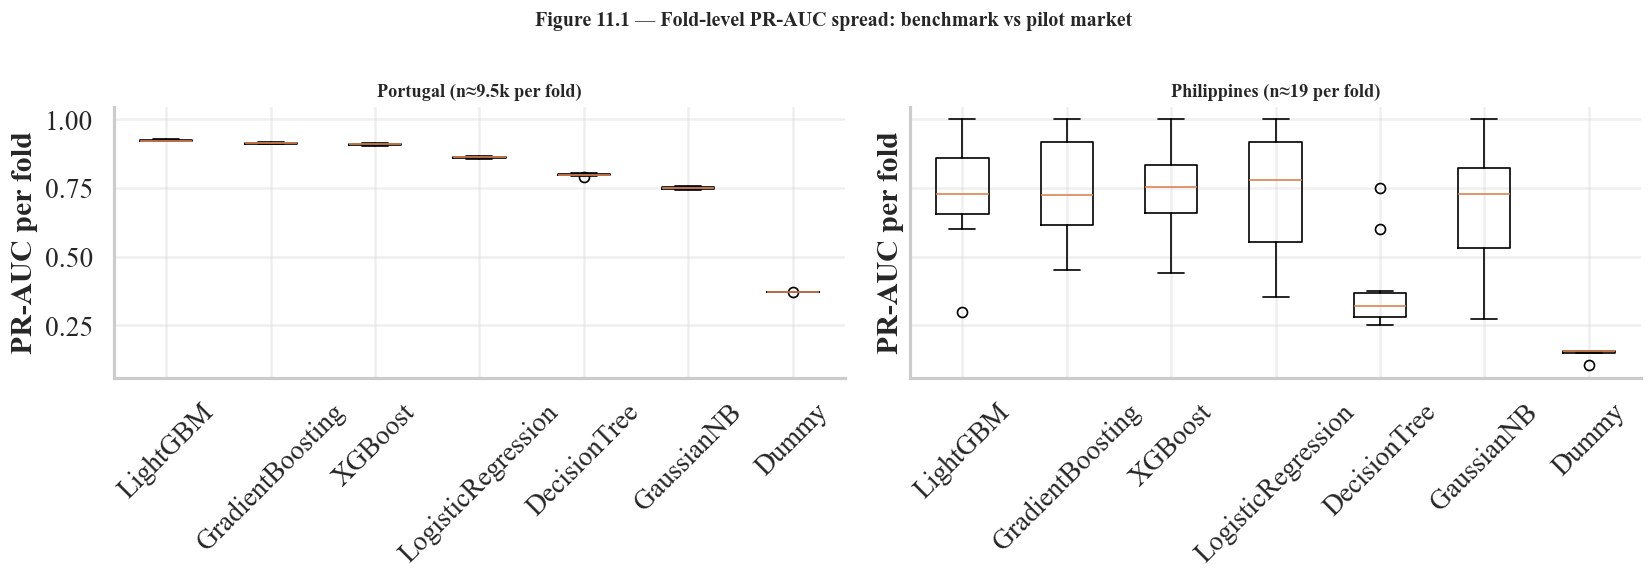

In [4]:
pt_folds_p = CV_DIR / "portugal_stratified_10fold_folds.csv"
ph_folds_p = CV_DIR / "philippine_stratified_10fold_folds.csv"
if pt_folds_p.exists() and ph_folds_p.exists():
    pt_folds = pd.read_csv(pt_folds_p)
    ph_folds = pd.read_csv(ph_folds_p)
    order = [e["algorithm"] for e in pt_cv["ranking"]]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, folds, title in [(axes[0], pt_folds, "Portugal (n≈9.5k per fold)"),
                             (axes[1], ph_folds, "Philippines (n≈19 per fold)")]:
        data = [folds.loc[folds["algorithm"] == a, "pr_auc"].dropna() for a in order]
        ax.boxplot(data, tick_labels=order, vert=True)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_ylabel("PR-AUC per fold")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(True, alpha=0.3)
    fig.suptitle("Figure 11.1 — Fold-level PR-AUC spread: benchmark vs pilot market",
                 fontsize=12, fontweight="bold")
    fig.tight_layout()
    save_thesis_figure(fig, 111, "transferability_cv_spread", FIG_DIR)
    plt.show()
else:
    print("[unavailable] fold-level CSVs — see docs/provenance.md")

## 11.4 The Philippine pilot champion (single chronological split)

Beyond cross-validation, the full production pipeline (chronological split → calibration → thresholds) was run once on the PH data via the plug-and-play adapter. **Read this section with its caveats — they are reproduced verbatim below because they are part of the result.**

### 11.3b Do Algorithm Rankings Survive the Market Change?

The table above compares values; this chart compares **order**. **How to read it:** each line is one algorithm; the left end is its PR-AUC rank in Portugal, the right end in the Philippines. Flat lines = the ranking transfers.

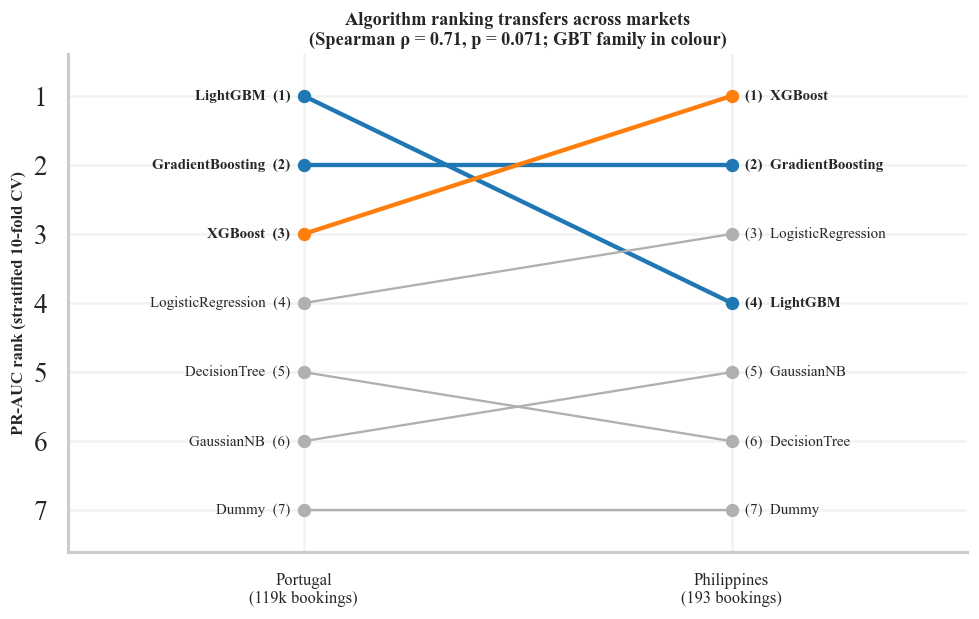

In [5]:
from scipy.stats import spearmanr
from src.eval.notebook_utils import plot_cross_market_rank_slope

if pt_cv and ph_cv:
    pt_rank = {e["algorithm"]: e["rank"] for e in pt_cv["ranking"]}
    ph_rank = {e["algorithm"]: e["rank"] for e in ph_cv["ranking"]}
    shared = [a for a in pt_rank if a in ph_rank]
    rho, pval = spearmanr([pt_rank[a] for a in shared], [ph_rank[a] for a in shared])
    fig = plot_cross_market_rank_slope(pt_cv["ranking"], ph_cv["ranking"], rho, pval)
    save_thesis_figure(fig, 112, "transferability_rank_slope", FIG_DIR)
    plt.show()

**Key Takeaway — Rank Transfer:** the gradient-boosted family stays at the top in both markets and the weak baselines stay at the bottom; only the ordering *within* the GBT trio reshuffles — consistent with the matched-capacity finding that those three are practically interchangeable. This is method-level transferability made visible in a single picture.

In [6]:
if transfer:
    print(f"Selected model family : {transfer['selected_model_family']}")
    print(f"Split sizes           : train={transfer['n_train']}, val={transfer['n_val']}, test={transfer['n_test']}")
    print(f"Test ROC-AUC          : {transfer['roc_auc_test']:.3f}")
    print(f"Test PR-AUC           : {transfer['pr_auc_test']:.3f}  (positive rate {transfer['positive_rate_test']:.0%})")
    print(f"Test ECE              : {transfer['ece_test']:.3f}")
    cm = pd.DataFrame(
        transfer["confusion_max_f1"],
        index=["actual stay", "actual cancel"],
        columns=["pred stay", "pred cancel"],
    )
    display(cm.style.set_caption("Confusion matrix @ max-F1 threshold (n_test = 20)"))
    print("\nCaveats (verbatim from the study output):")
    for c in transfer["caveats"]:
        print(f"  • {c}")

Selected model family : lightgbm
Split sizes           : train=154, val=19, test=20
Test ROC-AUC          : 0.611
Test PR-AUC           : 0.542  (positive rate 45%)
Test ECE              : 0.378


,pred stay,pred cancel
actual stay,10,1
actual cancel,9,0



Caveats (verbatim from the study output):
  • n_test = 20 rows; bootstrap 95% CIs on PR-AUC span roughly ±15 percentage points at this sample size
  • Feature set includes deposit_type and total_of_special_requests (two top-10 Portugal SHAP features) but still excludes market_segment, country, agent, customer_type, and previous_cancellations — the real PMS export does not capture them
  • No rolling-origin CV (insufficient data for the project's standard 3 folds); metrics use a single chronological 80/10/10 split
  • Constant-variance columns (Meals = 100% 'Breakfast (Complimentary)', Guest_Type = 100% 'Walk-In') were dropped during clean_raw_ph
  • Treat all reported metrics as directional, not as gates


## 11.5 Feature coverage: what the resort's PMS can and cannot see

Transferability is bounded by *data availability*, not just sample size. Several of Portugal's strongest predictors simply do not exist in the resort's PMS export.

In [7]:
from src.config import BOOKING_TIME_FEATURES

if transfer:
    ph_feats = set(transfer["feature_columns"])
    pt_feats = set(BOOKING_TIME_FEATURES)
    missing_in_ph = sorted(pt_feats - ph_feats)
    print(f"Portugal model features: {len(pt_feats)} | available in PH export: "
          f"{len(pt_feats & ph_feats)} | missing in PH: {len(missing_in_ph)}")
    print("\nPortugal features with NO PH equivalent (incl. strong PT predictors\nmarket_segment, country, agent, customer_type, previous_cancellations):")
    for f in missing_in_ph:
        print(f"  - {f}")

if ph_shap:
    top = pd.DataFrame(ph_shap["all_features_ranked"][:10])
    top.columns = ["Feature", "Mean |SHAP|"]
    display(
        top.style.format({"Mean |SHAP|": "{:.3f}"}).hide(axis="index").set_caption(
            "Table 11.3 — Philippine pilot: top-10 feature contributions (TreeSHAP)"
        )
    )

Portugal model features: 33 | available in PH export: 18 | missing in PH: 15

Portugal features with NO PH equivalent (incl. strong PT predictors
market_segment, country, agent, customer_type, previous_cancellations):
  - agent
  - arrival_date_day_of_month
  - arrival_date_month
  - arrival_date_year
  - country
  - customer_type
  - distribution_channel
  - had_company
  - hotel
  - is_repeated_guest
  - market_segment
  - meal
  - previous_bookings_not_canceled
  - previous_cancellations
  - required_car_parking_spaces


Feature,Mean |SHAP|
deposit_type,2.323
adr,1.829
reserved_room_type,0.844
revenue_at_risk,0.783
lead_time,0.718
month_cos,0.550
total_of_special_requests,0.481
adults,0.432
is_weekend_heavy,0.431
stays_in_weekend_nights,0.367


### 11.5b Which Factors Drive Cancellations in Each Market?

The coverage table above shows which features *exist*; this chart shows which features *matter*. **How to read it:** bars grow left for Portugal and right for the Philippines; each side is normalised to its own total (raw SHAP magnitudes are not comparable across different models), so bars are the **share of all explanatory signal** within that market. Green bars are factors that drive cancellations in **both** markets; grey notes mark Portugal drivers the resort's PMS cannot capture at all.

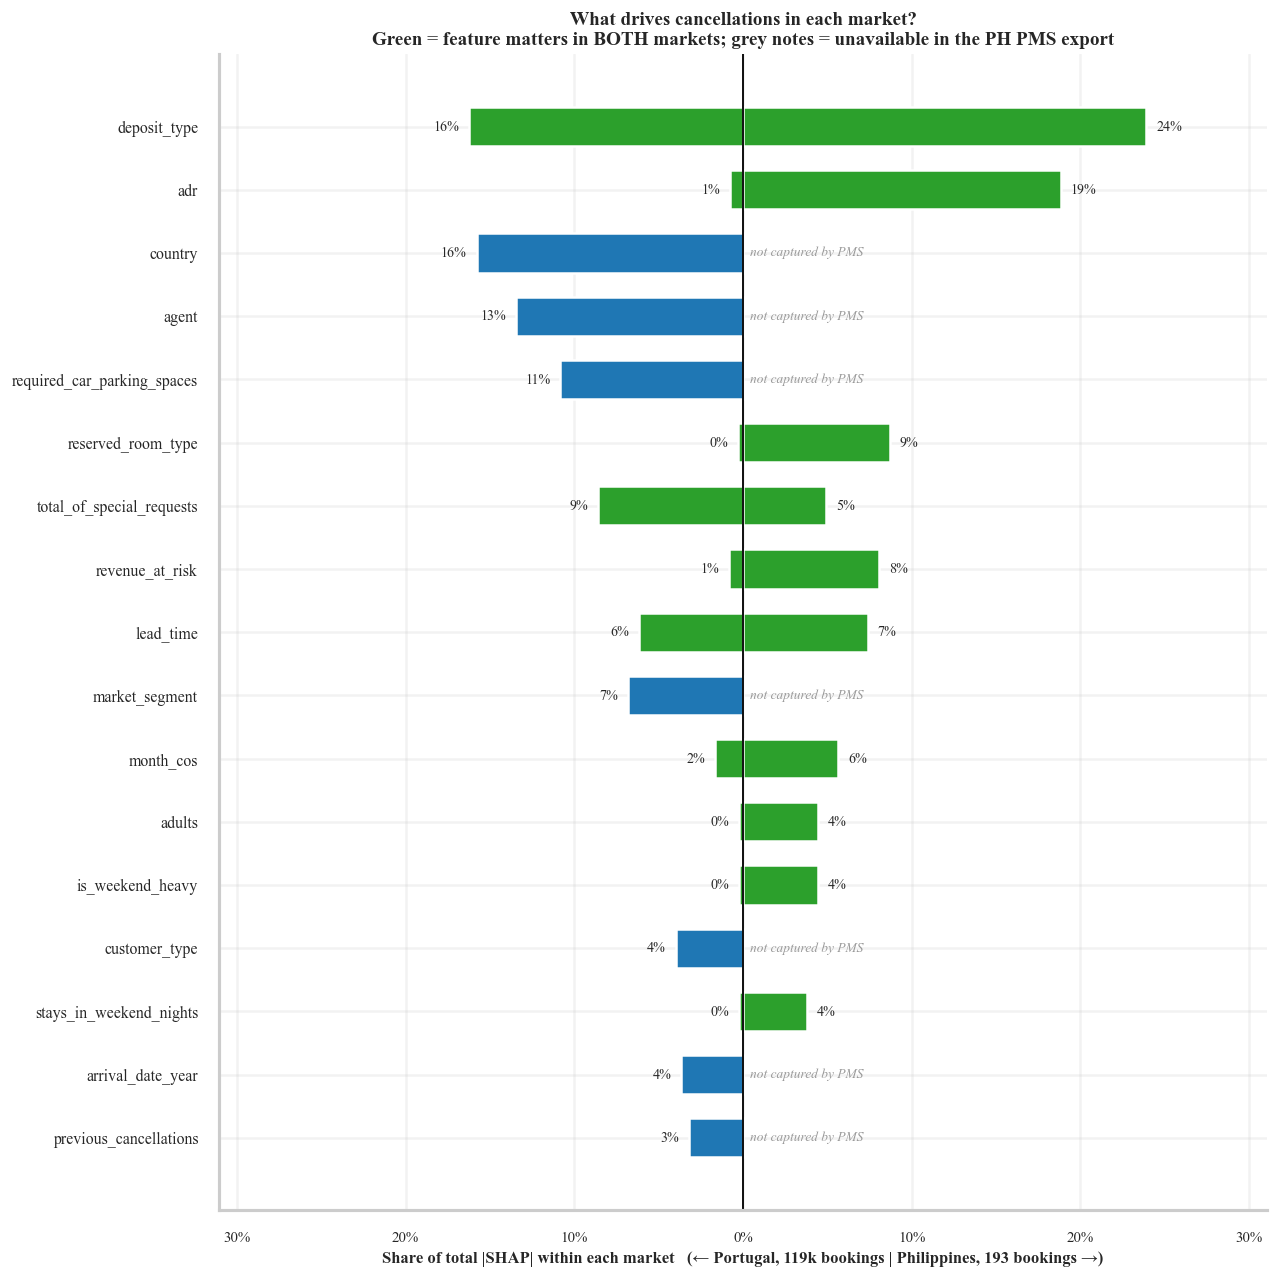

In [8]:
import joblib
from src.config import BOOKING_TIME_FEATURES
from src.eval.notebook_utils import (
    aggregate_encoded_shap_to_raw,
    plot_cross_market_feature_importance,
)

pt_imp_path = Path('../reports/thesis/shap_feature_importance.csv')
pt_model_path = Path('../artifacts/best_model.pkl')
if pt_imp_path.exists() and pt_model_path.exists() and ph_shap:
    imp = pd.read_csv(pt_imp_path).sort_values('feature_index')
    pipe = joblib.load(pt_model_path)
    enc_names = pipe.named_steps['preprocessor'].get_feature_names_out()
    pt_imp = aggregate_encoded_shap_to_raw(
        imp['mean_abs_shap'].to_numpy(), enc_names, BOOKING_TIME_FEATURES
    )
    ph_imp = {e['feature']: e['mean_abs_shap'] for e in ph_shap['all_features_ranked']}
    fig = plot_cross_market_feature_importance(pt_imp, ph_imp, top_n=10)
    save_thesis_figure(fig, 113, 'transferability_feature_importance', FIG_DIR)
    plt.show()
else:
    print('[unavailable] PT SHAP csv / model artifact / PH SHAP json — see docs/provenance.md')

**Key Takeaway — Shared Cancellation Drivers:** `deposit_type` is the single strongest cancellation signal in **both** markets (≈16% of all explanatory signal in Portugal, ≈24% in the Philippines), with `lead_time`, `total_of_special_requests`, and seasonality (`month_cos`) also mattering on both sides — behavioural findings that genuinely transfer. The differences are just as informative: Portugal's #2 and #3 drivers (`country`, `agent`) are *invisible* to the resort's PMS, and the Philippine model compensates by leaning on price signals (`adr`, `revenue_at_risk`) — exactly the fields the data-collection roadmap in the takeaway below prioritises.

**Key takeaway (whole notebook):** the **method transfers** — the identical pipeline, from cleaning to calibrated thresholds, ran end-to-end on a Philippine resort's PMS export with only the documented currency-constant changes (`ADR_MAX_VALID`, `FP_INTERVENTION_COST`). The **findings transfer directionally**: gradient-boosted trees top both markets, and `deposit_type`/`adr`-type signals dominate both feature rankings. What does **not** yet exist is statistical confirmation: with 193 bookings, confidence intervals span ±15 percentage points. The concrete recommendation for the resort is therefore operational, not algorithmic: log one full season of bookings (≥1,000 rows) with the missing fields (market segment, repeat-guest history), then re-run `make train` — the pipeline is already proven to handle the rest.